# RL Group Project: Clinical Treatment Optimisation — Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity, plus a creative extension:

- **Configuration A** — Tabular Sepsis MDP (716 discrete states, 25 actions): Q-Learning, SARSA, and Double Q-Learning.
- **Configuration B** — Continuous observation space (47-dimensional) with three clinical reality wrappers: DQN (with Double DQN updates) and Dueling DQN.
- **Creative Extension** — Systematic robustness analysis of learned policies under each clinical failure mode, and a clinical interpretability analysis of treatment preferences.

---
### Group Members
Fill in before submitting:

Name of the Group: **Group X**

```
Student 1: 
Student 2: 
Student 3: 
Student 4: 
Student 5: 
```


---
## 0. Setup & Imports

In [1]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import copy
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

# ── Fixed seeds for full reproducibility ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print(f'Config: sofa_bias={SOFA_BIAS}, lam={LAM}, gamma={GAMMA}')
print('Setup complete!')


Device : cpu
ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Config: sofa_bias=5.0, lam=0.02, gamma=1.0
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## 1. Environment Exploration

`ICU-Sepsis-v2` is a benchmark MDP built from real MIMIC-III patient data. Each episode simulates one ICU patient. The agent observes a discrete integer state (0–715) and selects one of 25 treatment actions (5 vasopressor levels × 5 IV fluid dose levels). The reward is sparse: **+1 at survival, 0 at death**, with a small intensity penalty `lam=0.02` at each step to discourage overtreatment.

In [2]:
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

raw    = env.unwrapped
P      = raw._tx_mat                   # (716, 25, 716)  P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716)
R      = (P * R_sasp).sum(axis=2)     # (716, 25)  E[r|s,a]

print(f'Observation space : {env.observation_space}')
print(f'Action space      : {env.action_space}')
print(f'Transition matrix : {P.shape}  (S x A x S\'')
print(f'Reward range      : [{R.min():.3f}, {R.max():.3f}]')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716)
Action space      : Discrete(25)
Transition matrix : (716, 25, 716)  (S x A x S'
Reward range      : [-0.020, 0.708]


In [3]:
# ── Random baseline (Config A) ────────────────────────────────────────────────
def run_random_baseline_A(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)

rand_returns_A, rand_lengths_A = run_random_baseline_A()
RAND_A_RETURN   = float(np.mean(rand_returns_A))
RAND_A_SURVIVAL = float(np.mean(rand_returns_A > 0)) * 100
print(f'Random baseline (Config A) | Return={RAND_A_RETURN:.4f} | Survival={RAND_A_SURVIVAL:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random baseline (Config A) | Return=0.5860 | Survival=68.9%


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


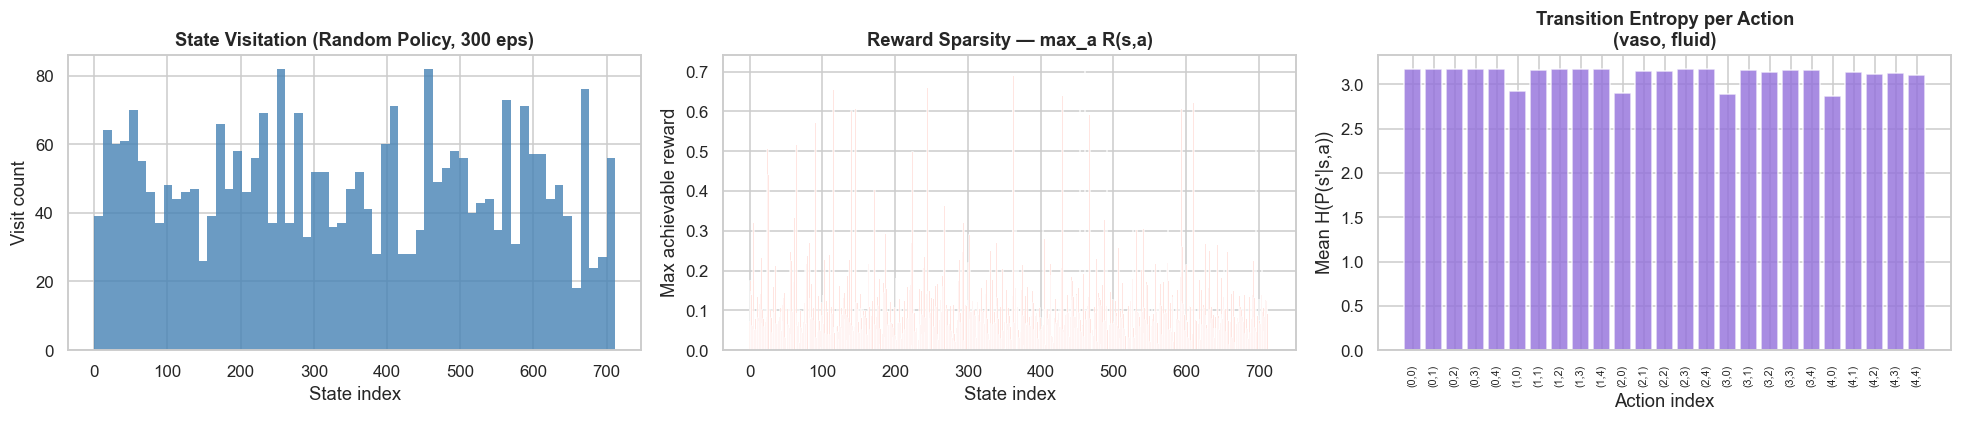

In [4]:
# ── Environment visualisation ─────────────────────────────────────────────────
import scipy.stats

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical_states = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical_states, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('State Visitation (Random Policy, 300 eps)', fontweight='bold')
axes[0].set_xlabel('State index'); axes[0].set_ylabel('Visit count')

# Reward sparsity
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_title('Reward Sparsity — max_a R(s,a)', fontweight='bold')
axes[1].set_xlabel('State index'); axes[1].set_ylabel('Max achievable reward')

# Transition entropy per action
entropy_per_action = np.array([
    np.mean([scipy.stats.entropy(P[s, a] + 1e-12) for s in range(N_STATES - 2)])
    for a in range(N_ACTIONS)
])
action_labels = [f'({i//5},{i%5})' for i in range(N_ACTIONS)]
axes[2].bar(range(N_ACTIONS), entropy_per_action, color='mediumpurple', alpha=0.8)
axes[2].set_title('Transition Entropy per Action\n(vaso, fluid)', fontweight='bold')
axes[2].set_xlabel('Action index'); axes[2].set_ylabel('Mean H(P(s\'|s,a))')
axes[2].set_xticks(range(N_ACTIONS))
axes[2].set_xticklabels(action_labels, rotation=90, fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular RL

With 716 states × 25 actions = 17,900 Q-table entries, tabular methods are entirely feasible. We implement three model-free TD algorithms:

| Property | Q-Learning | SARSA | Double Q-Learning |
|---|---|---|---|
| Policy type | Off-policy | On-policy | Off-policy |
| Update target | `max Q(s',·)` | `Q(s', a')` actual | `Q_B(s', argmax_A Q_A)` |
| Maximisation bias | Yes | No | No |
| Risk in stochastic env | Higher | Lower | Lower than Q-Learning |

All algorithms use ε-greedy exploration with identical exponential decay for a controlled comparison.

In [5]:
# ── Fixed evaluation function (Config A) ──────────────────────────────────────
def evaluate_tabular(Q, n_episodes=1000, seed=SEED):
    """
    Greedy evaluation of a tabular Q-table.
    Returns (mean_return, survival_pct, mean_ep_length).
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(np.argmax(Q[obs]))
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    returns = np.array(returns)
    return float(np.mean(returns)), float(np.mean(returns > 0)) * 100, float(np.mean(lengths))


## Config A — Algorithm 1: Q-Learning (Off-Policy TD Control)

Q-Learning updates using the **maximum** future Q-value, regardless of which action the behaviour policy would actually take. It learns the optimal Q* directly, independent of exploration noise.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \Big]$$

**Hyperparameter justification:** `α=0.1` balances convergence speed vs. stability on stochastic transitions. `γ=1.0` is set by the environment (survival reward not discounted). ε decays from 1.0 → 0.01 over 30k episodes via rate 0.9997, reaching ε=0.05 around episode 19k — ensuring thorough early exploration before settling into exploitation.

In [6]:
def train_q_learning(
    n_episodes=30_000, alpha=0.1, gamma=GAMMA,
    eps_start=1.0, eps_end=0.01, eps_decay=0.9997,
    eval_every=500, seed=SEED,
):
    """
    Q-Learning: off-policy TD control.
    Update: Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q         = np.zeros((N_STATES, N_ACTIONS))
    epsilon   = eps_start
    ep_returns, eval_log, eps_log = [], [], []

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q[obs]))
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            # Off-policy: bootstrap on max Q(s')
            Q[obs, action] += alpha * (r + gamma * np.max(Q[next_obs]) * (not done) - Q[obs, action])
            total_r += r; obs = next_obs
        epsilon = max(eps_end, epsilon * eps_decay)
        ep_returns.append(total_r); eps_log.append(epsilon)
        if (ep + 1) % eval_every == 0:
            mr, sr, _ = evaluate_tabular(Q, n_episodes=500)
            eval_log.append((ep + 1, mr, sr))
            print(f'[Q-Learning]    ep={ep+1:>6} | eps={epsilon:.4f} | return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return Q, np.array(ep_returns), eval_log, eps_log


print('Training Q-Learning...')
Q_ql, ql_train_ret, ql_eval, ql_eps = train_q_learning()
ql_mean, ql_surv, ql_len = evaluate_tabular(Q_ql)
print(f'\nQ-Learning FINAL | return={ql_mean:.4f} | survival={ql_surv:.1f}% | ep_len={ql_len:.1f}')


Training Q-Learning...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=   500 | eps=0.8607 | return=0.5972 | survival=66.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  1000 | eps=0.7408 | return=0.6028 | survival=68.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  1500 | eps=0.6376 | return=0.6114 | survival=69.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  2000 | eps=0.5488 | return=0.6112 | survival=69.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  2500 | e

## Config A — Algorithm 2: SARSA (On-Policy TD Control)

SARSA updates using the action the behaviour policy **actually selects** at `s'`, making it on-policy. It learns the value of the ε-greedy policy being executed, not the optimal policy — making it more conservative in stochastic environments.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma Q(s', a') - Q(s,a) \Big], \quad a' \sim \pi_\varepsilon(s')$$

In the sepsis context, SARSA's conservatism maps well to the clinical principle of *primum non nocere* — it avoids overcommitting to actions that appear optimal but may be risky under stochastic transitions.

In [7]:
def train_sarsa(
    n_episodes=30_000, alpha=0.1, gamma=GAMMA,
    eps_start=1.0, eps_end=0.01, eps_decay=0.9997,
    eval_every=500, seed=SEED,
):
    """
    SARSA: on-policy TD control.
    Update: Q(s,a) <- Q(s,a) + alpha * [r + gamma * Q(s', a') - Q(s,a)]
    where a' is sampled from the epsilon-greedy policy at s'.
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q         = np.zeros((N_STATES, N_ACTIONS))
    epsilon   = eps_start
    ep_returns, eval_log, eps_log = [], [], []

    def eps_greedy(s):
        if np.random.rand() < epsilon:
            return np.random.randint(N_ACTIONS)
        return int(np.argmax(Q[s]))

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        action = eps_greedy(obs)
        total_r, done = 0.0, False
        while not done:
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            next_action = eps_greedy(next_obs) if not done else 0
            # On-policy: bootstrap on Q(s', a') — the action we WILL take
            Q[obs, action] += alpha * (r + gamma * Q[next_obs, next_action] * (not done) - Q[obs, action])
            total_r += r; obs = next_obs; action = next_action
        epsilon = max(eps_end, epsilon * eps_decay)
        ep_returns.append(total_r); eps_log.append(epsilon)
        if (ep + 1) % eval_every == 0:
            mr, sr, _ = evaluate_tabular(Q, n_episodes=500)
            eval_log.append((ep + 1, mr, sr))
            print(f'[SARSA]         ep={ep+1:>6} | eps={epsilon:.4f} | return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return Q, np.array(ep_returns), eval_log, eps_log


print('Training SARSA...')
Q_sarsa, sarsa_train_ret, sarsa_eval, sarsa_eps = train_sarsa()
sarsa_mean, sarsa_surv, sarsa_len = evaluate_tabular(Q_sarsa)
print(f'\nSARSA FINAL | return={sarsa_mean:.4f} | survival={sarsa_surv:.1f}% | ep_len={sarsa_len:.1f}')


Training SARSA...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SARSA]         ep=   500 | eps=0.8607 | return=0.6175 | survival=66.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SARSA]         ep=  1000 | eps=0.7408 | return=0.6098 | survival=68.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SARSA]         ep=  1500 | eps=0.6376 | return=0.5915 | survival=66.8%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SARSA]         ep=  2000 | eps=0.5488 | return=0.5922 | survival=67.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[SARSA]         ep=  2500 | eps=0.

## Config A — Algorithm 3: Double Q-Learning

Standard Q-Learning suffers from **maximisation bias**: it uses the same Q-table to both select and evaluate the next action (`max_a Q(s',a)`), systematically overestimating Q-values in stochastic environments. Double Q-Learning eliminates this by maintaining two independent Q-tables — one selects the action, the other evaluates it:

$$a^* = \arg\max_a Q_A(s', a), \quad Q_A(s,a) \leftarrow Q_A(s,a) + \alpha \Big[ r + \gamma Q_B(s', a^*) - Q_A(s,a) \Big]$$

The two tables alternate roles randomly at each step. The greedy policy is derived from their average `(Q_A + Q_B) / 2`.

In [8]:
def train_double_q_learning(
    n_episodes=30_000, alpha=0.1, gamma=GAMMA,
    eps_start=1.0, eps_end=0.01, eps_decay=0.9997,
    eval_every=500, seed=SEED,
):
    """
    Double Q-Learning: two independent Q-tables eliminate maximisation bias.
    At each step, one table selects the greedy action, the other evaluates it.
    Behaviour policy uses eps-greedy on (Q_A + Q_B) / 2.
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q_A = np.zeros((N_STATES, N_ACTIONS))
    Q_B = np.zeros((N_STATES, N_ACTIONS))
    epsilon   = eps_start
    ep_returns, eval_log, eps_log = [], [], []

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            # Behaviour policy: eps-greedy on combined Q
            if np.random.rand() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q_A[obs] + Q_B[obs]))
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr

            if np.random.rand() < 0.5:
                # Update Q_A: select with Q_A, evaluate with Q_B
                best_a = int(np.argmax(Q_A[next_obs]))
                Q_A[obs, action] += alpha * (
                    r + gamma * Q_B[next_obs, best_a] * (not done) - Q_A[obs, action]
                )
            else:
                # Update Q_B: select with Q_B, evaluate with Q_A
                best_a = int(np.argmax(Q_B[next_obs]))
                Q_B[obs, action] += alpha * (
                    r + gamma * Q_A[next_obs, best_a] * (not done) - Q_B[obs, action]
                )
            total_r += r; obs = next_obs

        epsilon = max(eps_end, epsilon * eps_decay)
        ep_returns.append(total_r); eps_log.append(epsilon)
        if (ep + 1) % eval_every == 0:
            Q_avg = (Q_A + Q_B) / 2
            mr, sr, _ = evaluate_tabular(Q_avg, n_episodes=500)
            eval_log.append((ep + 1, mr, sr))
            print(f'[Double Q-Learn] ep={ep+1:>6} | eps={epsilon:.4f} | return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    Q_avg = (Q_A + Q_B) / 2
    return Q_avg, np.array(ep_returns), eval_log, eps_log


print('Training Double Q-Learning...')
Q_dql, dql_train_ret, dql_eval, dql_eps = train_double_q_learning()
dql_mean, dql_surv, dql_len = evaluate_tabular(Q_dql)
print(f'\nDouble Q-Learning FINAL | return={dql_mean:.4f} | survival={dql_surv:.1f}% | ep_len={dql_len:.1f}')


Training Double Q-Learning...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double Q-Learn] ep=   500 | eps=0.8607 | return=0.6410 | survival=67.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double Q-Learn] ep=  1000 | eps=0.7408 | return=0.6097 | survival=66.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double Q-Learn] ep=  1500 | eps=0.6376 | return=0.6177 | survival=68.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double Q-Learn] ep=  2000 | eps=0.5488 | return=0.6082 | survival=68.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double Q-Learn] e

## Config A — Results & Visualisation

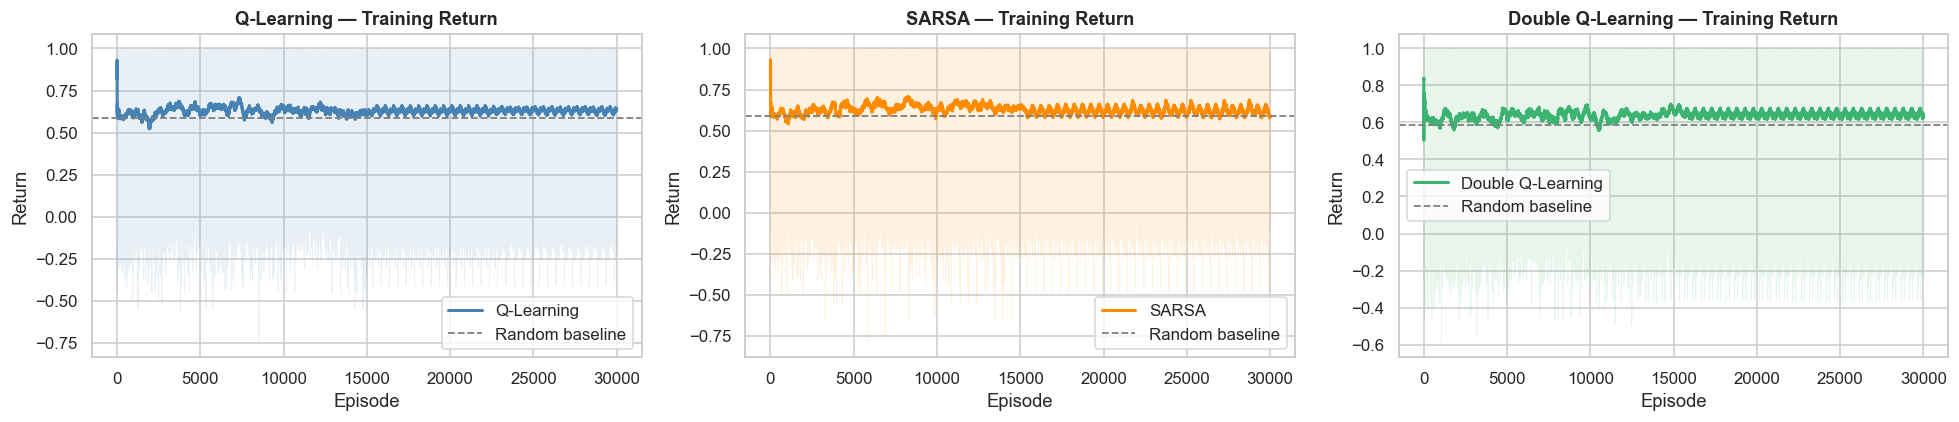

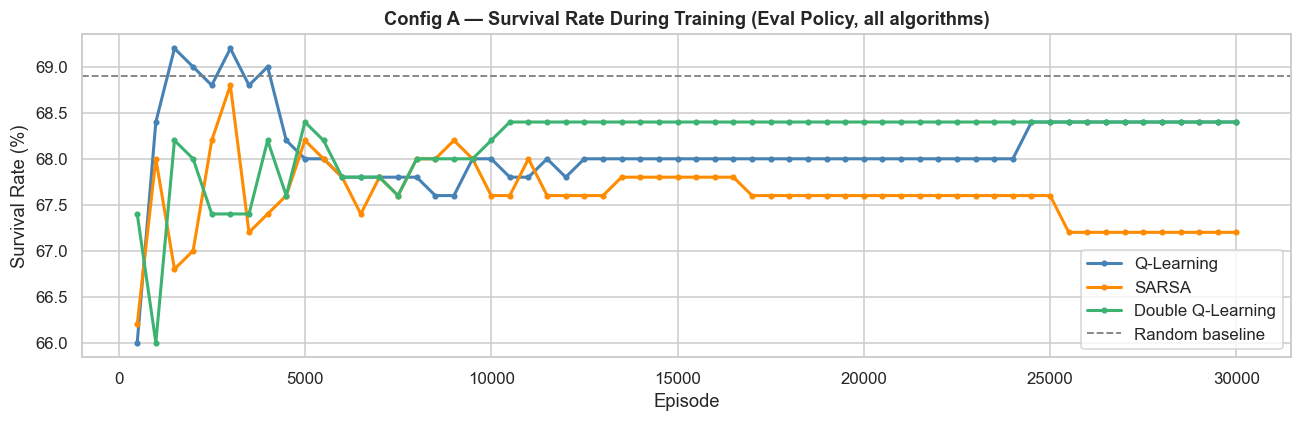

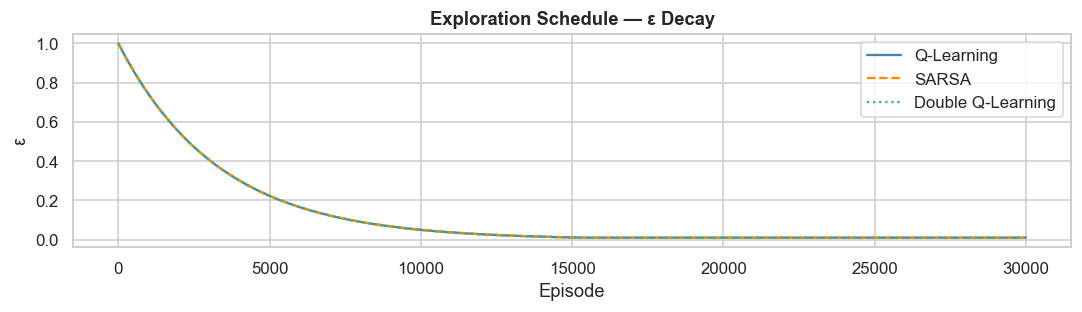

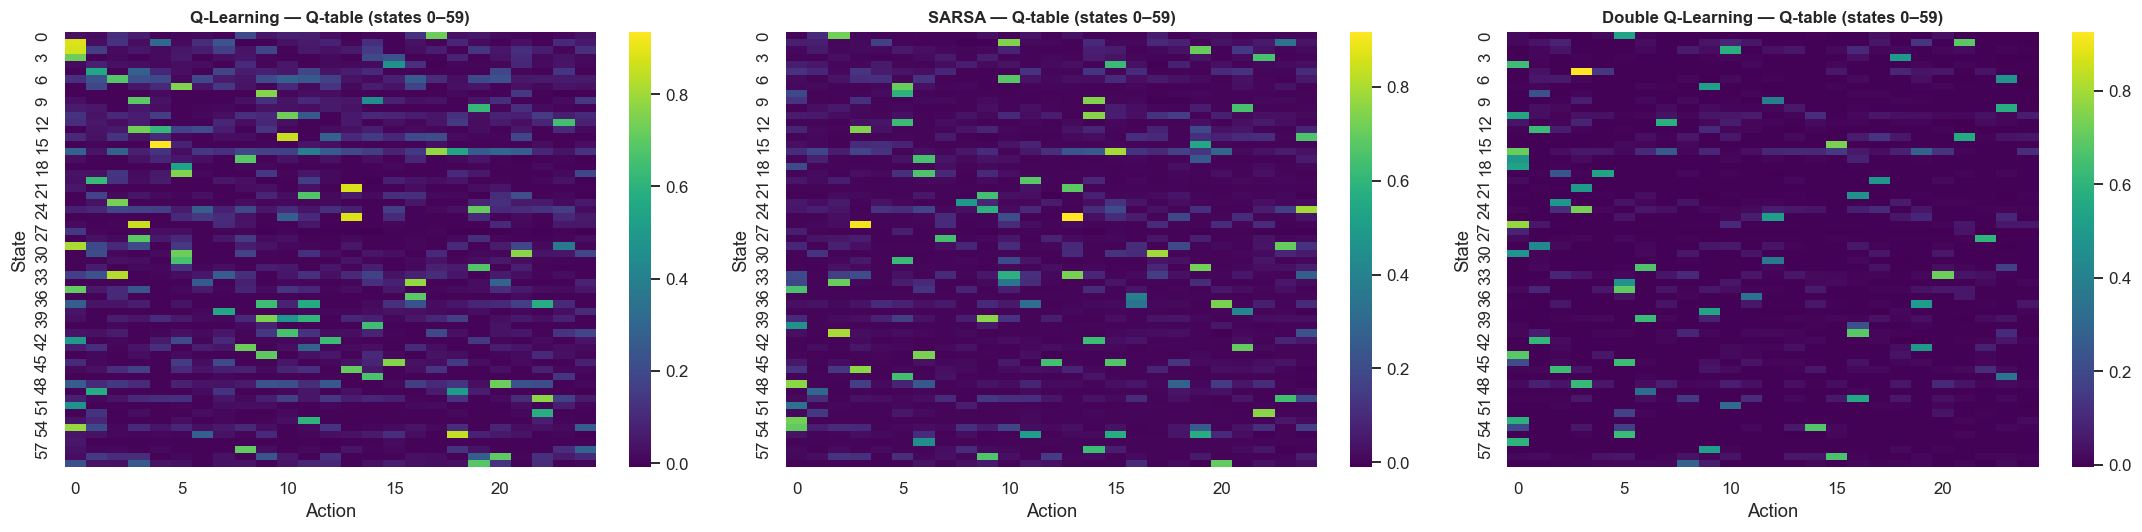

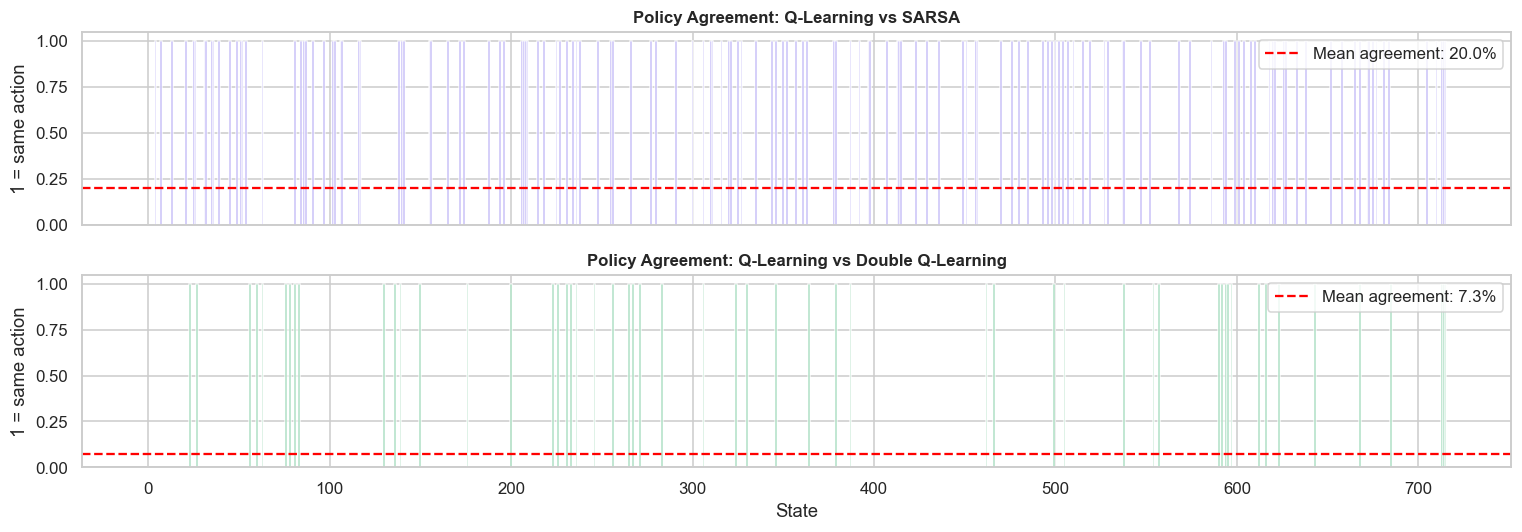

Q-Learning vs SARSA agreement          : 20.0%
Q-Learning vs Double Q-Learning agree. : 7.3%


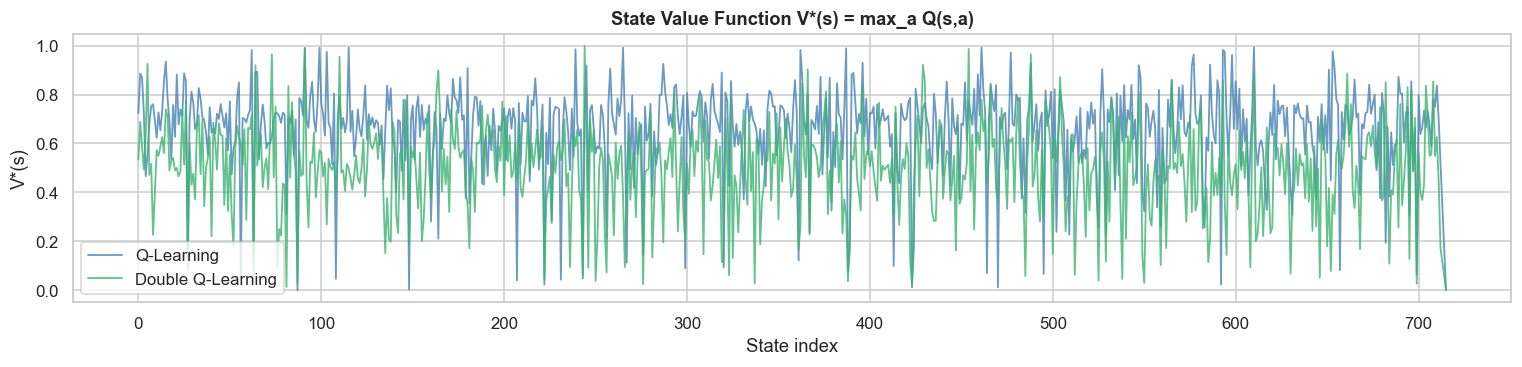

In [9]:
def smooth(x, w=200):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

# ── 1. Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, ret, label, c in zip(axes,
    [ql_train_ret, sarsa_train_ret, dql_train_ret],
    ['Q-Learning', 'SARSA', 'Double Q-Learning'],
    ['steelblue', 'darkorange', 'mediumseagreen']):
    ep = np.arange(1, len(ret) + 1)
    ax.plot(ep, ret, alpha=0.12, color=c, linewidth=0.5)
    ax.plot(ep, smooth(ret, 300), color=c, linewidth=2, label=label)
    ax.axhline(RAND_A_RETURN, color='grey', linestyle='--', lw=1.2, label='Random baseline')
    ax.set_title(f'{label} — Training Return', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Return'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_training_curves.png', bbox_inches='tight')
plt.show()

# ── 2. Eval survival convergence (all 3) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for edata, label, c in [
    (ql_eval,    'Q-Learning',       'steelblue'),
    (sarsa_eval, 'SARSA',            'darkorange'),
    (dql_eval,   'Double Q-Learning','mediumseagreen'),
]:
    ax.plot([x[0] for x in edata], [x[2] for x in edata],
            marker='o', ms=3, color=c, lw=2, label=label)
ax.axhline(RAND_A_SURVIVAL, color='grey', ls='--', lw=1.2, label='Random baseline')
ax.set_title('Config A — Survival Rate During Training (Eval Policy, all algorithms)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival Rate (%)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_eval_convergence.png', bbox_inches='tight')
plt.show()

# ── 3. Epsilon decay ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ql_eps,    color='steelblue',      lw=1.5, label='Q-Learning')
ax.plot(sarsa_eps, color='darkorange',     lw=1.5, ls='--', label='SARSA')
ax.plot(dql_eps,   color='mediumseagreen', lw=1.5, ls=':',  label='Double Q-Learning')
ax.set_title('Exploration Schedule — ε Decay', fontsize=12, fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('ε'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_epsilon.png', bbox_inches='tight')
plt.show()

# ── 4. Q-table heatmaps ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, Q, title in zip(axes,
    [Q_ql, Q_sarsa, Q_dql],
    ['Q-Learning', 'SARSA', 'Double Q-Learning']):
    sns.heatmap(Q[:60], ax=ax, cmap='viridis', cbar=True, xticklabels=5)
    ax.set_title(f'{title} — Q-table (states 0–59)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Action'); ax.set_ylabel('State')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_qtable_heatmap.png', bbox_inches='tight')
plt.show()

# ── 5. Policy agreement maps ──────────────────────────────────────────────────
greedy_ql    = np.argmax(Q_ql,    axis=1)
greedy_sarsa = np.argmax(Q_sarsa, axis=1)
greedy_dql   = np.argmax(Q_dql,   axis=1)
agr_ql_sarsa = (greedy_ql == greedy_sarsa).astype(float)
agr_ql_dql   = (greedy_ql == greedy_dql).astype(float)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, agr, title, c in zip(axes,
    [agr_ql_sarsa, agr_ql_dql],
    ['Q-Learning vs SARSA', 'Q-Learning vs Double Q-Learning'],
    ['mediumslateblue', 'mediumseagreen']):
    ax.bar(range(N_STATES), agr, width=1.0, color=c, alpha=0.8)
    mean_agr = agr[:-2].mean()
    ax.axhline(mean_agr, color='red', ls='--', lw=1.5,
               label=f'Mean agreement: {mean_agr*100:.1f}%')
    ax.set_title(f'Policy Agreement: {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('1 = same action'); ax.legend()
axes[1].set_xlabel('State')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_policy_agreement.png', bbox_inches='tight')
plt.show()
print(f'Q-Learning vs SARSA agreement          : {agr_ql_sarsa[:-2].mean()*100:.1f}%')
print(f'Q-Learning vs Double Q-Learning agree. : {agr_ql_dql[:-2].mean()*100:.1f}%')

# ── 6. State value function V*(s) = max_a Q(s,a) ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
nt = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
for Q, label, c in [
    (Q_ql,  'Q-Learning',        'steelblue'),
    (Q_dql, 'Double Q-Learning', 'mediumseagreen'),
]:
    V = Q.max(axis=1)
    ax.plot(nt, V[nt], color=c, lw=1.2, alpha=0.8, label=label)
ax.set_title('State Value Function V*(s) = max_a Q(s,a)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('State index'); ax.set_ylabel('V*(s)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_value_function.png', bbox_inches='tight')
plt.show()


In [10]:
# ── Config A Results Table ────────────────────────────────────────────────────
results_A = pd.DataFrame([
    {'Algorithm': 'Random Baseline',   'Mean Return': RAND_A_RETURN,
     'Survival Rate (%)': RAND_A_SURVIVAL, 'Avg Episode Length': float(np.mean(rand_lengths_A))},
    {'Algorithm': 'Q-Learning',        'Mean Return': ql_mean,    'Survival Rate (%)': ql_surv,    'Avg Episode Length': ql_len},
    {'Algorithm': 'SARSA',             'Mean Return': sarsa_mean, 'Survival Rate (%)': sarsa_surv, 'Avg Episode Length': sarsa_len},
    {'Algorithm': 'Double Q-Learning', 'Mean Return': dql_mean,   'Survival Rate (%)': dql_surv,   'Avg Episode Length': dql_len},
]).set_index('Algorithm').round(4)

print('=' * 65)
print('Config A — Final Results (1000 eval episodes, greedy policy)')
print('=' * 65)
print(results_A.to_string())


Config A — Final Results (1000 eval episodes, greedy policy)
                   Mean Return  Survival Rate (%)  Avg Episode Length
Algorithm                                                            
Random Baseline         0.5860               68.9              10.280
Q-Learning              0.6029               68.5               9.927
SARSA                   0.6026               68.1               9.722
Double Q-Learning       0.6270               70.4               9.744


---
# Config B — Deep RL on the Clinical ICU-Sepsis Environment

Config B introduces two challenges that make tabular methods infeasible:

1. **47-dimensional continuous observations** — the actual normalised physiological measurements from Komorowski et al. (2018): SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other variables. A Q-table would require one row per unique float vector — effectively infinite.

2. **Three clinical reality wrappers** simulating real ICU deployment challenges:
   - `EpisodicNoisyObsEnv`: monitor malfunction — observations corrupted by noise for the entire episode.
   - `EpisodicMissingObsEnv`: lab results unavailable — certain features zeroed out for the entire episode.
   - `AcuteEventEnv`: sudden irreversible patient deterioration (cardiac arrest, acute organ failure) independent of treatment.

We implement two deep RL algorithms with distinct architectures: **DQN** (standard Q-network with Double DQN updates) and **Dueling DQN** (decomposes Q into value and advantage streams).

In [11]:
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv, AcuteEventEnv, make_clinical_env,
)
import gymnasium as gym

env_clinical = make_clinical_env()
obs, info    = env_clinical.reset(seed=SEED)
OBS_DIM = env_clinical.observation_space.shape[0]   # 47
ACT_DIM = env_clinical.action_space.n               # 25
env_clinical.close()

print(f'Observation dim : {OBS_DIM}')
print(f'Action dim      : {ACT_DIM}')
print(f'Info keys       : {list(info.keys())}')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation dim : 47
Action dim      : 25
Info keys       : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']


In [12]:
# ── Random baseline (Config B) ────────────────────────────────────────────────
np.random.seed(SEED)
env_eval = make_clinical_env()
rand_returns_B = []
for _ in range(1000):
    obs, _ = env_eval.reset(seed=np.random.randint(100_000))
    total_r, done = 0.0, False
    while not done:
        obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
        total_r += r; done = te or tr
    rand_returns_B.append(total_r)
env_eval.close()

RAND_B_RETURN   = float(np.mean(rand_returns_B))
RAND_B_SURVIVAL = float(np.mean(np.array(rand_returns_B) > 0)) * 100
print(f'Random baseline (Config B) | Return={RAND_B_RETURN:.4f} | Survival={RAND_B_SURVIVAL:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random baseline (Config B) | Return=0.5709 | Survival=66.4%


In [13]:
# ── Fixed evaluation function (Config B) ─────────────────────────────────────
def evaluate_deep(policy_fn, n_episodes=500, seed=SEED):
    """
    Fixed evaluation for Config B.
    policy_fn: obs (np.array) -> action (int), deterministic/greedy.
    Returns (mean_return, survival_pct, mean_ep_length).
    """
    np.random.seed(seed)
    env_eval = make_clinical_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = policy_fn(obs)
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    returns = np.array(returns)
    return float(np.mean(returns)), float(np.mean(returns > 0)) * 100, float(np.mean(lengths))


# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(obs)).to(DEVICE),
            torch.LongTensor(actions).to(DEVICE),
            torch.FloatTensor(rewards).to(DEVICE),
            torch.FloatTensor(np.array(next_obs)).to(DEVICE),
            torch.FloatTensor(dones).to(DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


## Config B — Algorithm 1: DQN (with Double DQN updates)

DQN approximates Q(s, a) with a neural network and uses two stabilisation mechanisms:

- **Experience replay** (50k buffer): transitions are stored and sampled uniformly at random, breaking temporal correlations that cause catastrophic forgetting.
- **Target network** (hard sync every 200 steps): a frozen copy decouples TD targets from the parameters being trained.

We additionally apply **Double DQN**: the online network selects the greedy action, and the target network evaluates it. This decouples action selection from evaluation, eliminating the overestimation bias of standard DQN.

$$\mathcal{L}(\theta) = \mathbb{E}_{\mathcal{D}}\Big[\big(r + \gamma Q_{\theta^-}(s', \arg\max_{a'} Q_\theta(s', a')) - Q_\theta(s,a)\big)^2\Big]$$

In [14]:
class QNetwork(nn.Module):
    """Standard Q-network: obs -> Q-values for all actions."""
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )
    def forward(self, x): return self.net(x)


def train_dqn(
    n_episodes=3_000, gamma=GAMMA, lr=5e-4,
    batch_size=64, buffer_cap=50_000, target_update=200,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    warmup_steps=1000, eval_every=200, seed=SEED,
):
    """
    DQN with Double DQN updates, experience replay, target network,
    gradient clipping, and cosine annealing LR scheduler.
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env_train  = make_clinical_env()
    q_net      = QNetwork(OBS_DIM, ACT_DIM).to(DEVICE)
    target_net = copy.deepcopy(q_net).to(DEVICE); target_net.eval()
    optimizer  = optim.Adam(q_net.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=lr * 0.1)
    buffer     = ReplayBuffer(buffer_cap)

    epsilon = eps_start; total_steps = 0
    ep_returns, eval_log, losses = [], [], []

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if total_steps < warmup_steps or np.random.rand() < epsilon:
                action = np.random.randint(ACT_DIM)
            else:
                with torch.no_grad():
                    action = int(q_net(
                        torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            buffer.push(obs, action, r, next_obs, float(done))
            total_r += r; obs = next_obs; total_steps += 1

            if len(buffer) >= batch_size and total_steps > warmup_steps:
                s, a, rew, ns, d = buffer.sample(batch_size)
                with torch.no_grad():
                    # Double DQN: online selects, target evaluates
                    best_a    = q_net(ns).argmax(1)
                    td_target = rew + gamma * target_net(ns).gather(
                        1, best_a.unsqueeze(1)
                    ).squeeze(1) * (1 - d)
                q_pred = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss   = F.mse_loss(q_pred, td_target)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
                optimizer.step(); losses.append(loss.item())

            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

        epsilon = max(eps_end, epsilon * eps_decay)
        scheduler.step()
        ep_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            q_net.eval()
            def _pol(o):
                with torch.no_grad():
                    return int(q_net(
                        torch.FloatTensor(o).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            mr, sr, _ = evaluate_deep(_pol, n_episodes=300)
            eval_log.append((ep + 1, mr, sr))
            q_net.train()
            print(f'[DQN]     ep={ep+1:>5} | eps={epsilon:.4f} | '
                  f'lr={scheduler.get_last_lr()[0]:.5f} | '
                  f'return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return q_net, np.array(ep_returns), eval_log, losses


print('Training DQN (Double DQN updates)...')
dqn_net, dqn_train_ret, dqn_eval, dqn_losses = train_dqn()

dqn_net.eval()
def dqn_policy(obs):
    with torch.no_grad():
        return int(dqn_net(
            torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        ).argmax().item())

dqn_mean, dqn_surv, dqn_len = evaluate_deep(dqn_policy)
print(f'\nDQN FINAL | return={dqn_mean:.4f} | survival={dqn_surv:.1f}% | ep_len={dqn_len:.1f}')


Training DQN (Double DQN updates)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  200 | eps=0.3670 | lr=0.00050 | return=0.5593 | survival=65.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  400 | eps=0.1347 | lr=0.00048 | return=0.5923 | survival=67.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  600 | eps=0.0500 | lr=0.00046 | return=0.5706 | survival=66.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  800 | eps=0.0500 | lr=0.00043 | return=0.5776 | survival=67.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SO

## Config B — Algorithm 2: Dueling DQN

Dueling DQN decomposes the Q-function into two separate streams:

- **Value stream** $V(s)$: how good is this state, independent of action?
- **Advantage stream** $A(s, a)$: how much better is action $a$ compared to the average?

These are combined as: $Q(s,a) = V(s) + \Big(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')\Big)$

The mean subtraction ensures identifiability (prevents V and A from shifting by a constant). The key advantage is that the **value stream is updated by all actions simultaneously** — in states where action choice barely matters (e.g., a patient already in a critical state regardless of treatment), V(s) learns efficiently without waiting to visit every action. This is clinically relevant: some sepsis states are dominated by state severity, not treatment choice.

We retain Double DQN updates and all other stabilisation mechanisms, enabling a clean architectural comparison with standard DQN.

In [15]:
class DuelingQNetwork(nn.Module):
    """
    Dueling DQN architecture.
    Shared feature extractor -> separate value and advantage streams.
    Q(s,a) = V(s) + A(s,a) - mean_a'(A(s,a'))
    """
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        # Shared feature extractor
        self.feature = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.ReLU(),
        )
        # Value stream: state -> scalar V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )
        # Advantage stream: state -> per-action advantages A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, act_dim),
        )

    def forward(self, x):
        features  = self.feature(x)
        value     = self.value_stream(features)      # (B, 1)
        advantage = self.advantage_stream(features)  # (B, A)
        # Combine with mean subtraction for identifiability
        q = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q


def train_dueling_dqn(
    n_episodes=3_000, gamma=GAMMA, lr=5e-4,
    batch_size=64, buffer_cap=50_000, target_update=200,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    warmup_steps=1000, eval_every=200, seed=SEED,
):
    """
    Dueling DQN with Double DQN updates, experience replay,
    target network, gradient clipping, cosine LR scheduler.
    Identical training setup to DQN — only the network differs.
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env_train  = make_clinical_env()
    q_net      = DuelingQNetwork(OBS_DIM, ACT_DIM).to(DEVICE)
    target_net = copy.deepcopy(q_net).to(DEVICE); target_net.eval()
    optimizer  = optim.Adam(q_net.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=lr * 0.1)
    buffer     = ReplayBuffer(buffer_cap)

    epsilon = eps_start; total_steps = 0
    ep_returns, eval_log, losses = [], [], []
    val_log, adv_log = [], []   # track stream magnitudes for analysis

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if total_steps < warmup_steps or np.random.rand() < epsilon:
                action = np.random.randint(ACT_DIM)
            else:
                with torch.no_grad():
                    action = int(q_net(
                        torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            buffer.push(obs, action, r, next_obs, float(done))
            total_r += r; obs = next_obs; total_steps += 1

            if len(buffer) >= batch_size and total_steps > warmup_steps:
                s, a, rew, ns, d = buffer.sample(batch_size)
                with torch.no_grad():
                    # Double DQN: online selects, target evaluates
                    best_a    = q_net(ns).argmax(1)
                    td_target = rew + gamma * target_net(ns).gather(
                        1, best_a.unsqueeze(1)
                    ).squeeze(1) * (1 - d)
                q_pred = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss   = F.mse_loss(q_pred, td_target)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
                optimizer.step(); losses.append(loss.item())

                # Log stream magnitudes for interpretability
                with torch.no_grad():
                    feats = q_net.feature(s)
                    val_log.append(q_net.value_stream(feats).abs().mean().item())
                    adv_log.append(q_net.advantage_stream(feats).abs().mean().item())

            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

        epsilon = max(eps_end, epsilon * eps_decay)
        scheduler.step()
        ep_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            q_net.eval()
            def _pol(o):
                with torch.no_grad():
                    return int(q_net(
                        torch.FloatTensor(o).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            mr, sr, _ = evaluate_deep(_pol, n_episodes=300)
            eval_log.append((ep + 1, mr, sr))
            q_net.train()
            print(f'[Dueling] ep={ep+1:>5} | eps={epsilon:.4f} | '
                  f'lr={scheduler.get_last_lr()[0]:.5f} | '
                  f'return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return q_net, np.array(ep_returns), eval_log, losses, val_log, adv_log


print('Training Dueling DQN...')
duel_net, duel_train_ret, duel_eval, duel_losses, val_log, adv_log = train_dueling_dqn()

duel_net.eval()
def duel_policy(obs):
    with torch.no_grad():
        return int(duel_net(
            torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        ).argmax().item())

duel_mean, duel_surv, duel_len = evaluate_deep(duel_policy)
print(f'\nDueling DQN FINAL | return={duel_mean:.4f} | survival={duel_surv:.1f}% | ep_len={duel_len:.1f}')


Training Dueling DQN...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  200 | eps=0.3670 | lr=0.00050 | return=0.6202 | survival=70.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  400 | eps=0.1347 | lr=0.00048 | return=0.6147 | survival=70.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  600 | eps=0.0500 | lr=0.00046 | return=0.5813 | survival=66.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  800 | eps=0.0500 | lr=0.00043 | return=0.5676 | survival=65.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Due

## Config B — Results & Visualisation

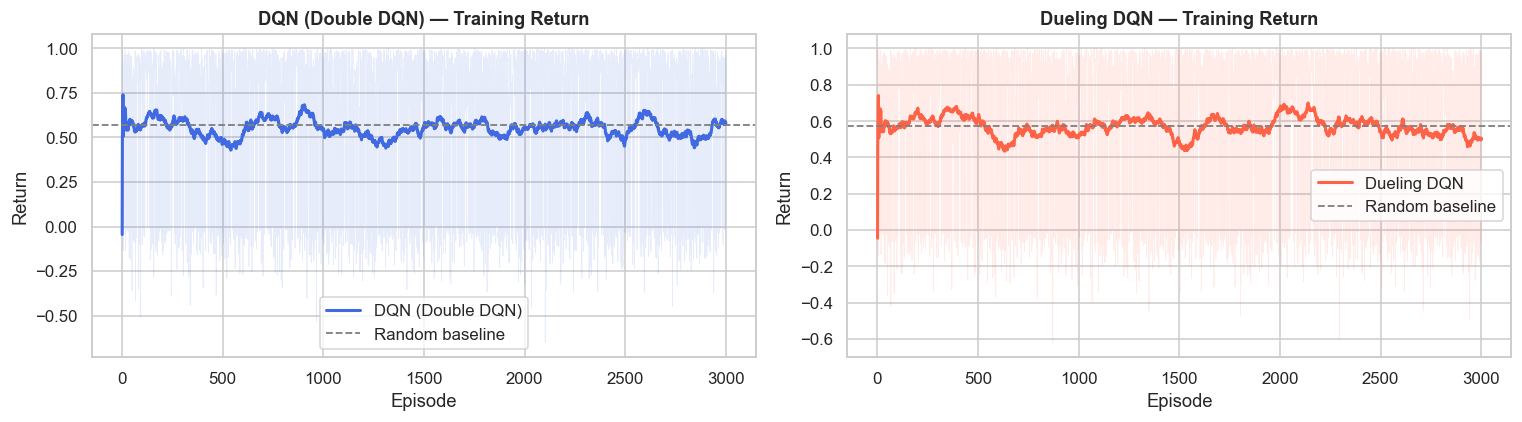

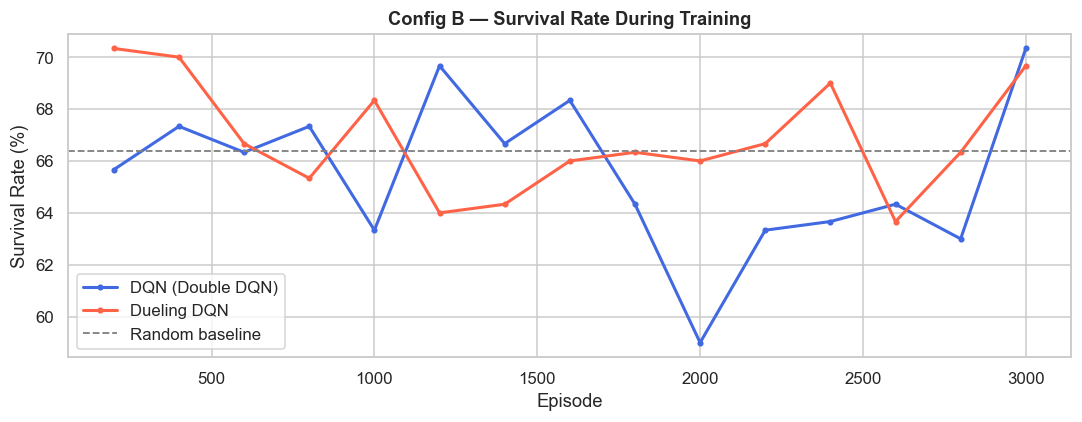

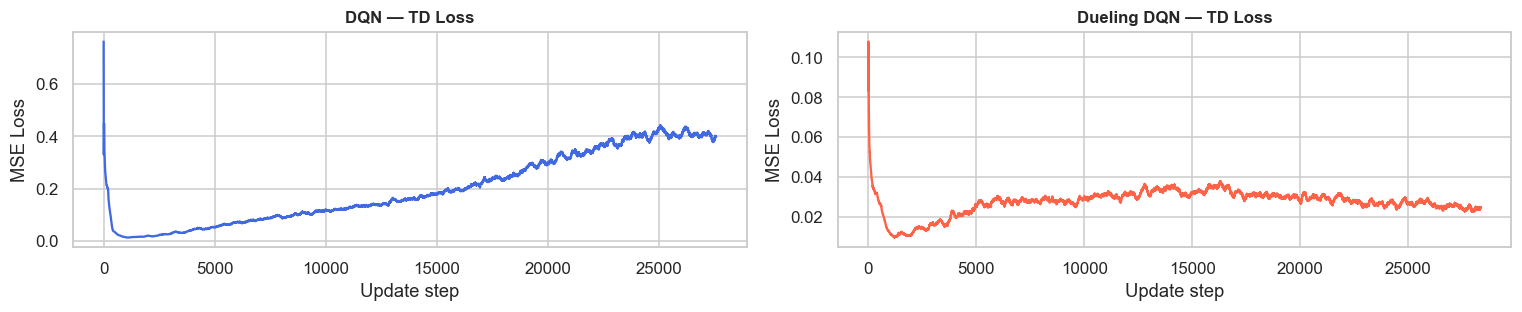

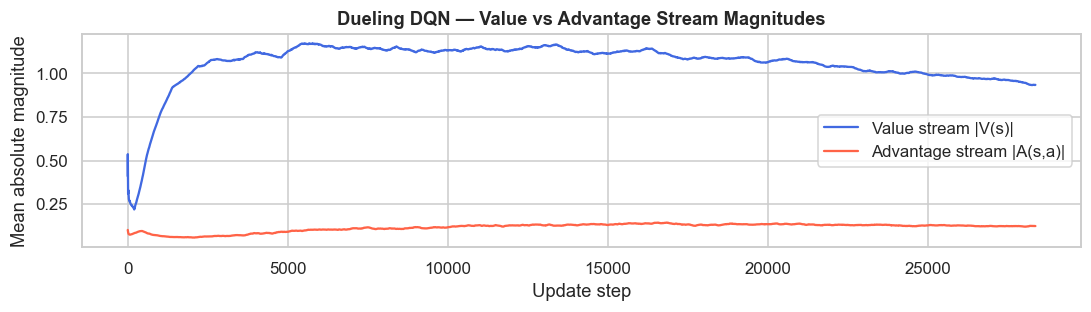

Config B — Final Results (500 eval episodes, greedy policy)
                  Mean Return  Survival Rate (%) Avg Ep Length
Algorithm                                                     
Random Baseline      0.570945               66.4             -
DQN (Double DQN)     0.573065               66.6         10.18
Dueling DQN          0.598915               67.4         9.436


In [16]:
# ── 1. Training reward curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ret, label, c in zip(axes,
    [dqn_train_ret, duel_train_ret],
    ['DQN (Double DQN)', 'Dueling DQN'],
    ['royalblue', 'tomato']):
    ep = np.arange(1, len(ret) + 1)
    ax.plot(ep, ret, alpha=0.12, color=c, lw=0.5)
    ax.plot(ep, smooth(ret, 100), color=c, lw=2, label=label)
    ax.axhline(RAND_B_RETURN, color='grey', ls='--', lw=1.2, label='Random baseline')
    ax.set_title(f'{label} — Training Return', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Return'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_training_curves.png', bbox_inches='tight')
plt.show()

# ── 2. Eval survival convergence ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for edata, label, c in [
    (dqn_eval,  'DQN (Double DQN)', 'royalblue'),
    (duel_eval, 'Dueling DQN',      'tomato'),
]:
    ax.plot([x[0] for x in edata], [x[2] for x in edata],
            marker='o', ms=3, color=c, lw=2, label=label)
ax.axhline(RAND_B_SURVIVAL, color='grey', ls='--', lw=1.2, label='Random baseline')
ax.set_title('Config B — Survival Rate During Training', fontsize=12, fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival Rate (%)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_eval_convergence.png', bbox_inches='tight')
plt.show()

# ── 3. TD Loss curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(smooth(dqn_losses,  200), color='royalblue', lw=1.5, label='DQN')
axes[0].set_title('DQN — TD Loss', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Update step'); axes[0].set_ylabel('MSE Loss')

axes[1].plot(smooth(duel_losses, 200), color='tomato', lw=1.5, label='Dueling DQN')
axes[1].set_title('Dueling DQN — TD Loss', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Update step'); axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_loss_curves.png', bbox_inches='tight')
plt.show()

# ── 4. Dueling DQN stream magnitudes ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(smooth(val_log, 200), color='royalblue', lw=1.5, label='Value stream |V(s)|')
ax.plot(smooth(adv_log, 200), color='tomato',    lw=1.5, label='Advantage stream |A(s,a)|')
ax.set_title('Dueling DQN — Value vs Advantage Stream Magnitudes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Mean absolute magnitude'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_dueling_streams.png', bbox_inches='tight')
plt.show()

# ── 5. Results table ──────────────────────────────────────────────────────────
results_B = pd.DataFrame([
    {'Algorithm': 'Random Baseline', 'Mean Return': RAND_B_RETURN,
     'Survival Rate (%)': RAND_B_SURVIVAL, 'Avg Ep Length': '-'},
    {'Algorithm': 'DQN (Double DQN)', 'Mean Return': dqn_mean,
     'Survival Rate (%)': dqn_surv,  'Avg Ep Length': dqn_len},
    {'Algorithm': 'Dueling DQN',      'Mean Return': duel_mean,
     'Survival Rate (%)': duel_surv, 'Avg Ep Length': duel_len},
]).set_index('Algorithm')

print('=' * 60)
print('Config B — Final Results (500 eval episodes, greedy policy)')
print('=' * 60)
print(results_B.to_string())


---
# Config A vs Config B — Comparative Analysis

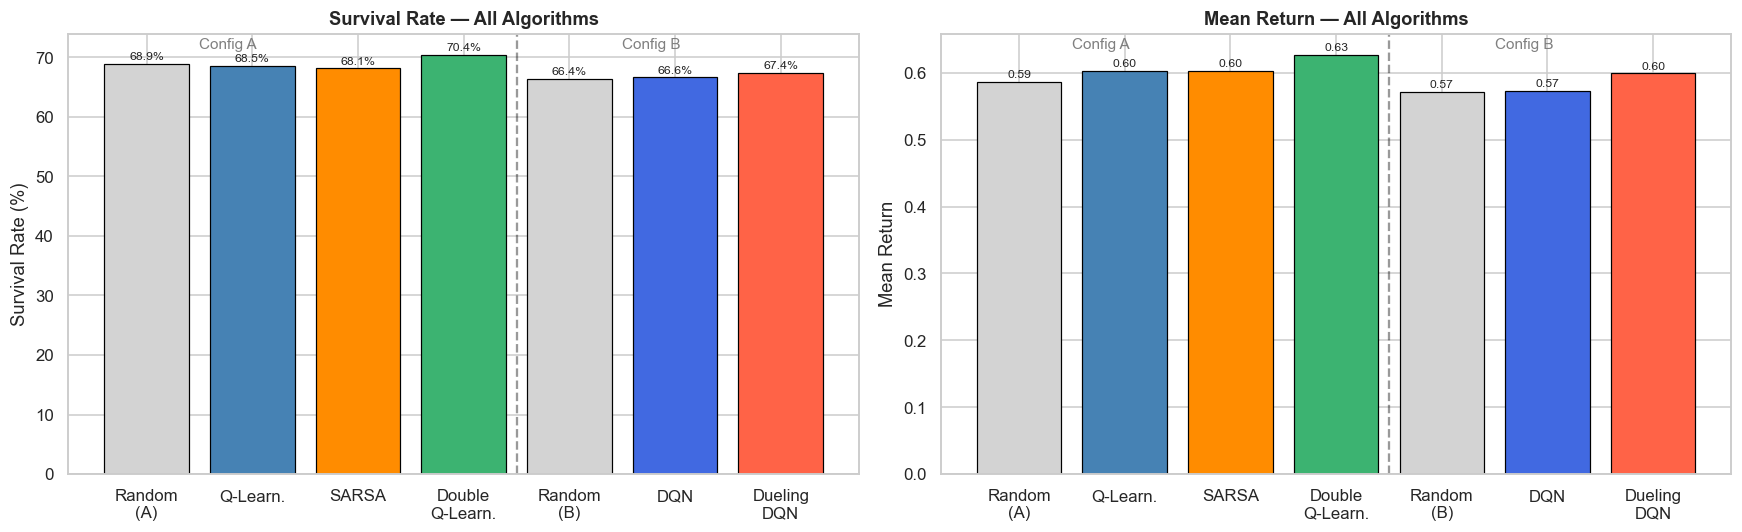

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

algorithms = ['Random\n(A)', 'Q-Learn.', 'SARSA', 'Double\nQ-Learn.',
              'Random\n(B)', 'DQN', 'Dueling\nDQN']
survivals  = [RAND_A_SURVIVAL, ql_surv, sarsa_surv, dql_surv,
              RAND_B_SURVIVAL, dqn_surv, duel_surv]
mean_rets  = [RAND_A_RETURN,   ql_mean,  sarsa_mean, dql_mean,
              RAND_B_RETURN,   dqn_mean, duel_mean]
colors     = ['lightgrey', 'steelblue', 'darkorange', 'mediumseagreen',
              'lightgrey', 'royalblue', 'tomato']

for ax, values, ylabel, title in zip(axes,
    [survivals, mean_rets],
    ['Survival Rate (%)', 'Mean Return'],
    ['Survival Rate — All Algorithms', 'Mean Return — All Algorithms']):
    bars = ax.bar(algorithms, values, color=colors, edgecolor='black', lw=0.8)
    ax.axvline(3.5, color='black', lw=1.5, ls='--', alpha=0.4)
    ax.text(0.5,  max(values) * 1.015, 'Config A', fontsize=10, color='grey')
    ax.text(4.5,  max(values) * 1.015, 'Config B', fontsize=10, color='grey')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.005,
                f'{v:.2f}' if ylabel == 'Mean Return' else f'{v:.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/comparative_all.png', bbox_inches='tight')
plt.show()


---
# Creative Extension — Robustness Analysis & Clinical Interpretability

## Motivation

Config B trains agents on the full combined clinical environment. This raises two clinically critical questions:

1. **Which failure mode degrades performance most?** Knowing this prioritises deployment infrastructure investments — monitor calibration vs. lab availability vs. acute event detection systems.

2. **What treatment strategy does the agent learn?** A high survival rate is insufficient — we must verify the agent is not overmedicating (excessive vasopressor + IV fluid causes fluid overload and ischaemia).

## Extension 1: Per-Wrapper Robustness Analysis

We evaluate both agents across 2,000 episodes and stratify results by which wrappers were active, computing survival rates separately for: clean episodes, noisy-only, missing-only, both, and acute vs. non-acute.

In [18]:
def evaluate_by_wrapper(policy_fn, n_episodes=2000, seed=SEED):
    """
    Evaluates policy over n_episodes and stratifies by active wrappers.
    Uses info dict flags: noisy_episode, missing_features, acute_event.
    """
    np.random.seed(seed)
    env_eval = make_clinical_env()
    buckets = {
        'clean':      [],
        'noisy':      [],
        'missing':    [],
        'noisy+miss': [],
        'no_acute':   [],
        'acute':      [],
        'all':        [],
    }

    for _ in range(n_episodes):
        obs, info  = env_eval.reset(seed=np.random.randint(100_000))
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False
        total_r, done = 0.0, False

        while not done:
            action = policy_fn(obs)
            obs, r, te, tr, info = env_eval.step(action)
            total_r += r; done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        buckets['all'].append(total_r)
        if ep_noisy and ep_missing: buckets['noisy+miss'].append(total_r)
        elif ep_noisy:              buckets['noisy'].append(total_r)
        elif ep_missing:            buckets['missing'].append(total_r)
        else:                       buckets['clean'].append(total_r)
        if ep_acute:                buckets['acute'].append(total_r)
        else:                       buckets['no_acute'].append(total_r)

    env_eval.close()
    return {
        k: {'n': len(v),
            'survival': float(np.mean(np.array(v) > 0)) * 100 if v else float('nan'),
            'mean_return': float(np.mean(v)) if v else float('nan')}
        for k, v in buckets.items()
    }


print('Evaluating DQN robustness by wrapper condition...')
dqn_robustness  = evaluate_by_wrapper(dqn_policy,  n_episodes=2000)
print('Evaluating Dueling DQN robustness by wrapper condition...')
duel_robustness = evaluate_by_wrapper(duel_policy, n_episodes=2000)
print('Done.')


Evaluating DQN robustness by wrapper condition...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Evaluating Dueling DQN robustness by wrapper condition...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Done.


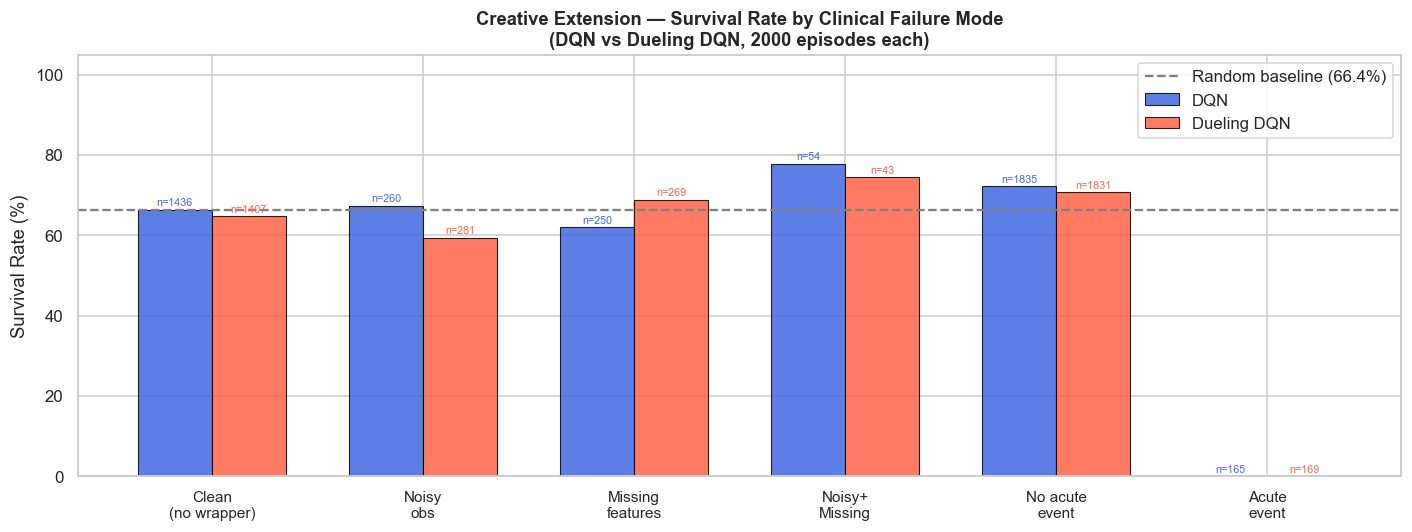


Robustness Table:
                     DQN n  DQN Survival %  Dueling n  Dueling Survival %
Condition                                                                
Clean\n(no wrapper)   1436            66.4       1407                64.7
Noisy\nobs             260            67.3        281                59.4
Missing\nfeatures      250            62.0        269                68.8
Noisy+\nMissing         54            77.8         43                74.4
No acute\nevent       1835            72.2       1831                70.7
Acute\nevent           165             0.0        169                 0.0


In [19]:
# ── Robustness visualisation ──────────────────────────────────────────────────
conditions  = ['clean', 'noisy', 'missing', 'noisy+miss', 'no_acute', 'acute']
cond_labels = ['Clean\n(no wrapper)', 'Noisy\nobs', 'Missing\nfeatures',
               'Noisy+\nMissing', 'No acute\nevent', 'Acute\nevent']

dqn_surv_by_cond  = [dqn_robustness[c]['survival']  for c in conditions]
duel_surv_by_cond = [duel_robustness[c]['survival'] for c in conditions]
dqn_n  = [dqn_robustness[c]['n']  for c in conditions]
duel_n = [duel_robustness[c]['n'] for c in conditions]

x = np.arange(len(conditions)); width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, dqn_surv_by_cond,  width,
               label='DQN',         color='royalblue', alpha=0.85, edgecolor='black', lw=0.7)
bars2 = ax.bar(x + width/2, duel_surv_by_cond, width,
               label='Dueling DQN', color='tomato',    alpha=0.85, edgecolor='black', lw=0.7)
ax.axhline(RAND_B_SURVIVAL, color='grey', ls='--', lw=1.5,
           label=f'Random baseline ({RAND_B_SURVIVAL:.1f}%)')

for bar, n in zip(bars1, dqn_n):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={n}', ha='center', va='bottom', fontsize=7, color='royalblue')
for bar, n in zip(bars2, duel_n):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={n}', ha='center', va='bottom', fontsize=7, color='tomato')

ax.set_xticks(x); ax.set_xticklabels(cond_labels, fontsize=10)
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Creative Extension — Survival Rate by Clinical Failure Mode\n'
             '(DQN vs Dueling DQN, 2000 episodes each)',
             fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_robustness_by_wrapper.png', bbox_inches='tight')
plt.show()

rob_df = pd.DataFrame({
    'Condition':          cond_labels,
    'DQN n':              dqn_n,
    'DQN Survival %':     [round(v, 1) for v in dqn_surv_by_cond],
    'Dueling n':          duel_n,
    'Dueling Survival %': [round(v, 1) for v in duel_surv_by_cond],
}).set_index('Condition')
print('\nRobustness Table:')
print(rob_df.to_string())


## Extension 2: Clinical Interpretability — Treatment Preferences

The 25 actions form a 5×5 grid: vasopressor level (0=none, 4=max) × IV fluid dose (0=none, 4=max). We analyse the action frequency and survival rate per action cell for each agent, and compare treatment intensity against the random baseline.

In [20]:
def collect_action_distribution(policy_fn, n_episodes=1000, seed=SEED):
    """Collect action frequency and per-action survival rate."""
    np.random.seed(seed)
    env_eval = make_clinical_env()
    action_counts = np.zeros(ACT_DIM)
    survival_by_action = [[] for _ in range(ACT_DIM)]

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        ep_actions, total_r, done = [], 0.0, False
        while not done:
            action = policy_fn(obs)
            ep_actions.append(action)
            action_counts[action] += 1
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; done = te or tr
        for a in ep_actions:
            survival_by_action[a].append(float(total_r > 0))

    env_eval.close()
    action_freq = action_counts / action_counts.sum()
    surv_by_act = np.array([
        float(np.mean(survival_by_action[a])) if survival_by_action[a] else float('nan')
        for a in range(ACT_DIM)
    ])
    return action_freq, surv_by_act


def random_policy(obs):
    return np.random.randint(ACT_DIM)


print('Collecting action distributions...')
rand_freq,  rand_surv_by_act = collect_action_distribution(random_policy)
dqn_freq,   dqn_surv_by_act  = collect_action_distribution(dqn_policy)
duel_freq,  duel_surv_by_act  = collect_action_distribution(duel_policy)
print('Done.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Done.


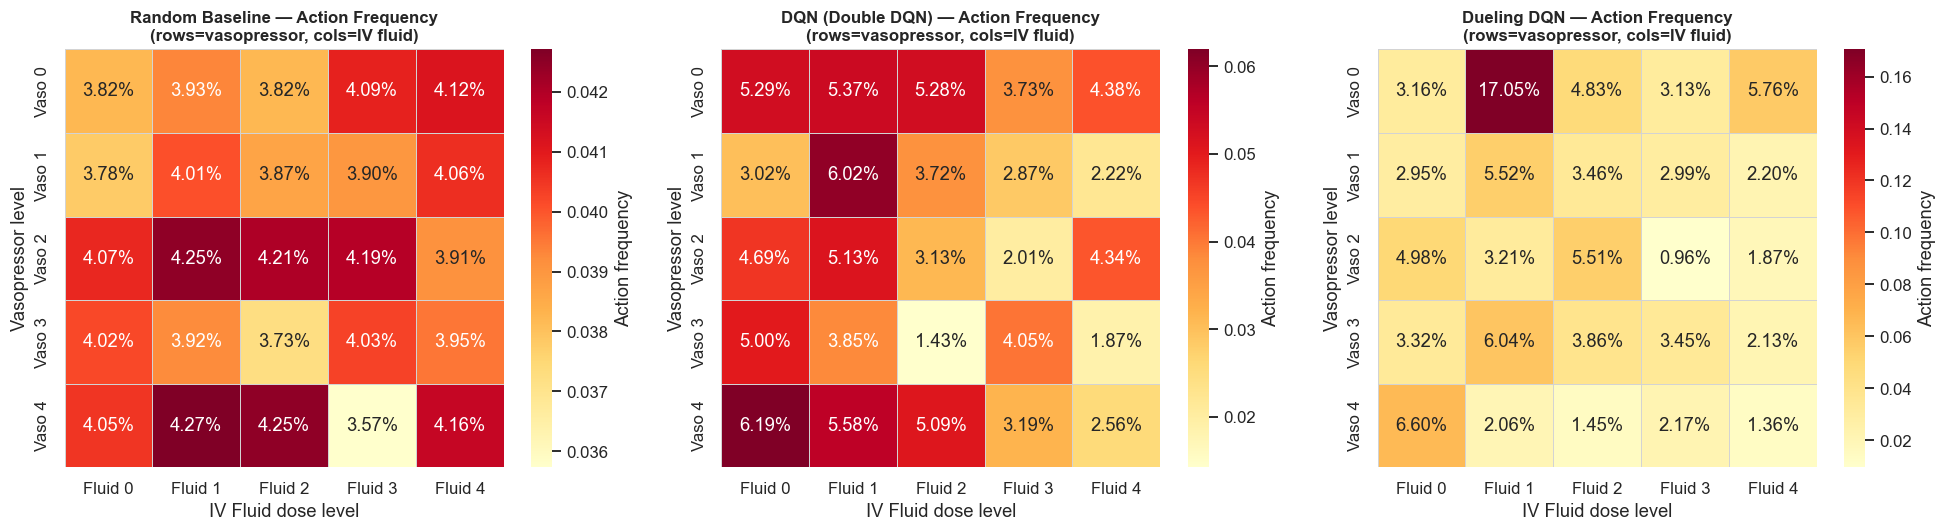

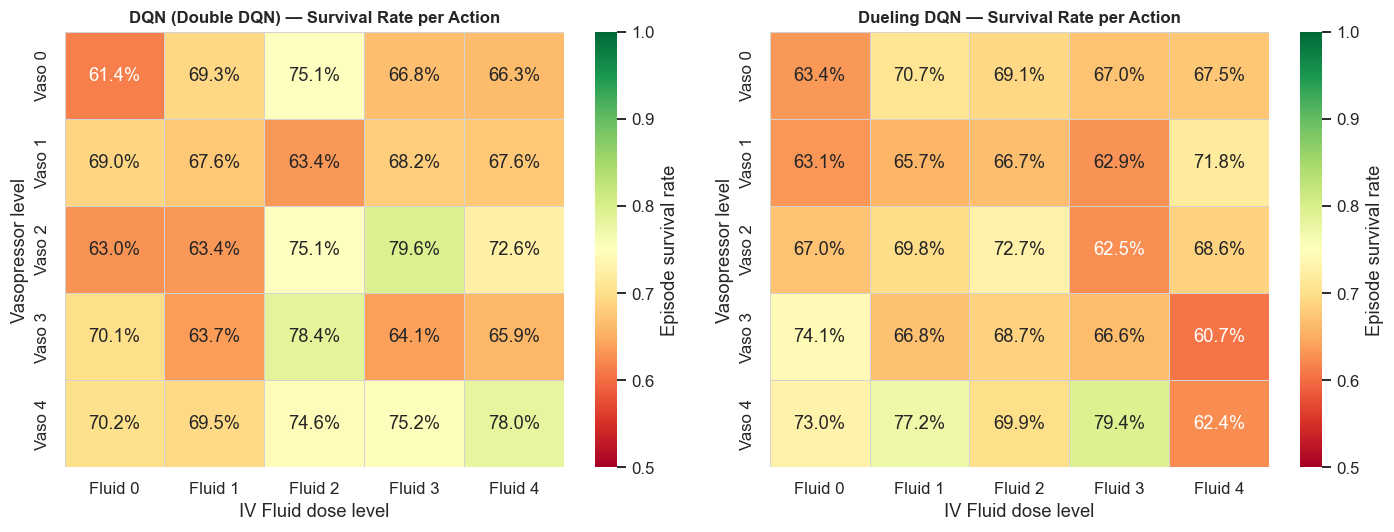

In [21]:
def to_grid(arr): return arr.reshape(5, 5)

# ── Action frequency heatmaps (5×5) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, freq, title in zip(axes,
    [rand_freq, dqn_freq, duel_freq],
    ['Random Baseline', 'DQN (Double DQN)', 'Dueling DQN']):
    sns.heatmap(
        to_grid(freq), ax=ax, cmap='YlOrRd', annot=True, fmt='.2%',
        xticklabels=[f'Fluid {i}' for i in range(5)],
        yticklabels=[f'Vaso {i}'  for i in range(5)],
        cbar_kws={'label': 'Action frequency'},
        linewidths=0.5, linecolor='lightgrey',
    )
    ax.set_title(f'{title} — Action Frequency\n(rows=vasopressor, cols=IV fluid)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('IV Fluid dose level'); ax.set_ylabel('Vasopressor level')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_action_heatmaps.png', bbox_inches='tight')
plt.show()

# ── Survival rate per action heatmaps ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, title in zip(axes,
    [dqn_surv_by_act, duel_surv_by_act],
    ['DQN (Double DQN)', 'Dueling DQN']):
    sns.heatmap(
        to_grid(surv), ax=ax, cmap='RdYlGn', annot=True, fmt='.1%',
        xticklabels=[f'Fluid {i}' for i in range(5)],
        yticklabels=[f'Vaso {i}'  for i in range(5)],
        vmin=0.5, vmax=1.0,
        cbar_kws={'label': 'Episode survival rate'},
        linewidths=0.5, linecolor='lightgrey',
    )
    ax.set_title(f'{title} — Survival Rate per Action',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('IV Fluid dose level'); ax.set_ylabel('Vasopressor level')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_survival_by_action.png', bbox_inches='tight')
plt.show()


## Extension 3: Treatment Intensity Analysis

In [22]:
def compute_treatment_intensity(policy_fn, n_episodes=1000, seed=SEED):
    """Compute mean vasopressor level, mean fluid level, intensity score, and histograms."""
    np.random.seed(seed)
    env_eval = make_clinical_env()
    vaso_levels, fluid_levels = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        done = False
        while not done:
            action = policy_fn(obs)
            vaso_levels.append(action // 5)
            fluid_levels.append(action %  5)
            obs, _, te, tr, _ = env_eval.step(action)
            done = te or tr
    env_eval.close()
    return {
        'mean_vaso':   float(np.mean(vaso_levels)),
        'mean_fluid':  float(np.mean(fluid_levels)),
        'intensity':   float(np.mean(vaso_levels) + np.mean(fluid_levels)),
        'vaso_hist':   np.bincount(vaso_levels,  minlength=5) / len(vaso_levels),
        'fluid_hist':  np.bincount(fluid_levels, minlength=5) / len(fluid_levels),
    }


print('Computing treatment intensity...')
intensity_rand = compute_treatment_intensity(random_policy)
intensity_dqn  = compute_treatment_intensity(dqn_policy)
intensity_duel = compute_treatment_intensity(duel_policy)

for label, d in [('Random', intensity_rand), ('DQN', intensity_dqn), ('Dueling', intensity_duel)]:
    print(f"{label:<10} | Vaso={d['mean_vaso']:.2f} | Fluid={d['mean_fluid']:.2f} | Intensity={d['intensity']:.2f}")


Computing treatment intensity...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random     | Vaso=2.01 | Fluid=2.00 | Intensity=4.01
DQN        | Vaso=1.95 | Fluid=1.72 | Intensity=3.68
Dueling    | Vaso=1.61 | Fluid=1.63 | Intensity=3.25


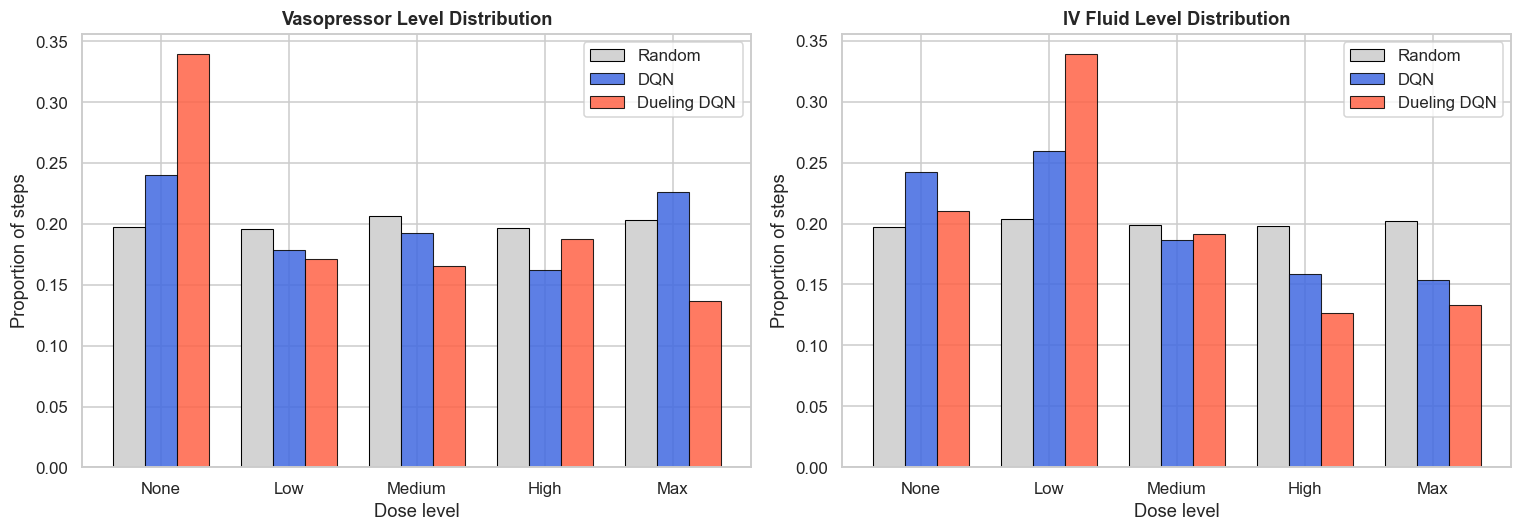

Treatment Intensity Summary:
             Mean Vaso  Mean Fluid  Intensity (0-8)
Policy                                             
Random           2.011       2.003            4.014
DQN              1.955       1.722            3.677
Dueling DQN      1.611       1.634            3.245


In [23]:
# ── Treatment intensity visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
level_lbls = ['None', 'Low', 'Medium', 'High', 'Max']
x = np.arange(5); w = 0.25

for ax, key, title in zip(axes,
    ['vaso_hist', 'fluid_hist'],
    ['Vasopressor Level Distribution', 'IV Fluid Level Distribution']):
    ax.bar(x - w, intensity_rand[key], w, label='Random',      color='lightgrey', edgecolor='black', lw=0.7)
    ax.bar(x,     intensity_dqn[key],  w, label='DQN',         color='royalblue', edgecolor='black', lw=0.7, alpha=0.85)
    ax.bar(x + w, intensity_duel[key], w, label='Dueling DQN', color='tomato',    edgecolor='black', lw=0.7, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(level_lbls)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Proportion of steps'); ax.set_xlabel('Dose level'); ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_treatment_intensity.png', bbox_inches='tight')
plt.show()

int_df = pd.DataFrame([
    {'Policy': 'Random',      'Mean Vaso': intensity_rand['mean_vaso'],  'Mean Fluid': intensity_rand['mean_fluid'],  'Intensity (0-8)': intensity_rand['intensity']},
    {'Policy': 'DQN',         'Mean Vaso': intensity_dqn['mean_vaso'],   'Mean Fluid': intensity_dqn['mean_fluid'],   'Intensity (0-8)': intensity_dqn['intensity']},
    {'Policy': 'Dueling DQN', 'Mean Vaso': intensity_duel['mean_vaso'],  'Mean Fluid': intensity_duel['mean_fluid'],  'Intensity (0-8)': intensity_duel['intensity']},
]).set_index('Policy').round(3)
print('Treatment Intensity Summary:')
print(int_df.to_string())


---
# Final Results Summary

In [24]:
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)

print('\n--- Config A (Tabular) ---')
print(results_A.round(4).to_string())

print('\n--- Config B (Deep RL) ---')
print(results_B.round(4).to_string())

print('\n--- Creative Extension: Robustness by Failure Mode ---')
print(rob_df.to_string())

print('\n--- Creative Extension: Treatment Intensity ---')
print(int_df.to_string())

print('\n--- Plots saved ---')
for f in sorted(os.listdir(PLOTS_DIR)):
    print(f'   {f}')


FINAL RESULTS SUMMARY

--- Config A (Tabular) ---
                   Mean Return  Survival Rate (%)  Avg Episode Length
Algorithm                                                            
Random Baseline         0.5860               68.9              10.280
Q-Learning              0.6029               68.5               9.927
SARSA                   0.6026               68.1               9.722
Double Q-Learning       0.6270               70.4               9.744

--- Config B (Deep RL) ---
                  Mean Return  Survival Rate (%) Avg Ep Length
Algorithm                                                     
Random Baseline        0.5709               66.4             -
DQN (Double DQN)       0.5731               66.6         10.18
Dueling DQN            0.5989               67.4         9.436

--- Creative Extension: Robustness by Failure Mode ---
                     DQN n  DQN Survival %  Dueling n  Dueling Survival %
Condition                                                